In [ ]:
import pandas as pd
import numpy as np

In [ ]:
sales_data = pd.read_csv('/content/sales_data_missing_values_handled.csv')
sales_data.head()

,Patient Name,Doctor Name,Date,Product,Batch No.,Expiry Date,Qty,Rate,Discount,Amount,Tax
0,patient1,doctor1,27-01-2024,4-QUIN-DROPS,A-3048,31-07-2025,1,156.0,9.0,141.96,12
1,patient2,doctor2,27-10-2023,A TO Z SYP,22490786,31-03-2024,1,176.0,9.0,160.16,18
2,patient3,doctor3,01-02-2024,A TO Z SYP,23660073,28-02-2025,1,190.0,9.0,172.90,18
3,SUKANTHI,doctor4,20-03-2024,A TO Z SYP,23660081,28-02-2025,1,190.0,9.0,172.90,18
4,AYISHA ACHIPRA,JAYAKRISHNAN,03-02-2024,A TO Z NS+,23490075,30-06-2024,15,9.4,8.0,129.72,12


In [ ]:
sales_data.shape

(50889, 11)

In [ ]:
#create a column for total
sales_data['Total'] = sales_data['Amount'] + (sales_data['Tax']/100)*sales_data['Qty']*sales_data['Rate']
# Convert to datetime
sales_data['Date'] = pd.to_datetime(sales_data['Date'])
# Create a YearMonth column (as a string like '2023-01')
sales_data['YearMonth'] = sales_data['Date'].dt.to_period('M').astype(str)
#Create column for unit cost
sales_data['UnitCost'] = sales_data['Total']/sales_data['Qty']
#Renme BatchNo. to BatchNo
sales_data.rename(columns={'Batch No.': 'BatchNo'}, inplace=True)
sales_data.head()


<ipython-input-4-3d4948acb735>:4: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  sales_data['Date'] = pd.to_datetime(sales_data['Date'])


,Patient Name,Doctor Name,Date,Product,BatchNo,Expiry Date,Qty,Rate,Discount,Amount,Tax,Total,YearMonth,UnitCost
0,patient1,doctor1,2024-01-27,4-QUIN-DROPS,A-3048,31-07-2025,1,156.0,9.0,141.96,12,160.68,2024-01,160.680
1,patient2,doctor2,2023-10-27,A TO Z SYP,22490786,31-03-2024,1,176.0,9.0,160.16,18,191.84,2023-10,191.840
2,patient3,doctor3,2024-02-01,A TO Z SYP,23660073,28-02-2025,1,190.0,9.0,172.90,18,207.10,2024-02,207.100
3,SUKANTHI,doctor4,2024-03-20,A TO Z SYP,23660081,28-02-2025,1,190.0,9.0,172.90,18,207.10,2024-03,207.100
4,AYISHA ACHIPRA,JAYAKRISHNAN,2024-02-03,A TO Z NS+,23490075,30-06-2024,15,9.4,8.0,129.72,12,146.64,2024-02,9.776


In [ ]:
#Remove unwanted columns
sales_data.drop(['Amount','Tax','Rate','Patient Name','Doctor Name','Discount'],axis=1,inplace=True)
sales_data.head()

,Date,Product,BatchNo,Expiry Date,Qty,Total,YearMonth,UnitCost
0,2024-01-27,4-QUIN-DROPS,A-3048,31-07-2025,1,160.68,2024-01,160.680
1,2023-10-27,A TO Z SYP,22490786,31-03-2024,1,191.84,2023-10,191.840
2,2024-02-01,A TO Z SYP,23660073,28-02-2025,1,207.10,2024-02,207.100
3,2024-03-20,A TO Z SYP,23660081,28-02-2025,1,207.10,2024-03,207.100
4,2024-02-03,A TO Z NS+,23490075,30-06-2024,15,146.64,2024-02,9.776


In [ ]:
#Sort the purchase data
purchase_data = pd.read_csv('/content/cleaned_purchase_data.csv')
purchase_data.head()

,Product,A/cDate,Bill No,BillDat,Supplier,BatchNo,Expiry,Qty,Amount,TaxAmt,Total
0,4-QUIN-DROPS,16-05-2024,ADF4114,16-05-2024,ATTUPURAM DRUGS,DO3H003,31-07-2025,2,216.17,25.94,242.11
1,A TO Z NS DROPS,06-05-2024,7352,04-05-2024,SUNANDA ASSOCIATES,23079AZPF,31-01-2025,2,95.60,17.21,112.81
2,A TO Z NS+,15-05-2024,5443,15-05-2024,NEDSONS AGENCIES,24490008,30-06-2025,15,100.88,18.16,119.04
3,A TO Z NS+,15-05-2024,7278,15-05-2024,KANMONEY PHARMA,23491286,31-05-2025,45,308.94,55.61,364.55
4,AB FLO CAP 15'S,09-04-2024,300442,08-04-2024,REVATHEEJAYA MEDICALS,006K23RA,31-10-2025,45,507.28,60.87,568.15


In [ ]:
purchase_data.shape

(3446, 11)

In [ ]:
#Create column for UnitCost
purchase_data['UnitCost'] = purchase_data['Total']/purchase_data['Qty']
purchase_data.head()

,Product,A/cDate,Bill No,BillDat,Supplier,BatchNo,Expiry,Qty,Amount,TaxAmt,Total,UnitCost
0,4-QUIN-DROPS,16-05-2024,ADF4114,16-05-2024,ATTUPURAM DRUGS,DO3H003,31-07-2025,2,216.17,25.94,242.11,121.055000
1,A TO Z NS DROPS,06-05-2024,7352,04-05-2024,SUNANDA ASSOCIATES,23079AZPF,31-01-2025,2,95.60,17.21,112.81,56.405000
2,A TO Z NS+,15-05-2024,5443,15-05-2024,NEDSONS AGENCIES,24490008,30-06-2025,15,100.88,18.16,119.04,7.936000
3,A TO Z NS+,15-05-2024,7278,15-05-2024,KANMONEY PHARMA,23491286,31-05-2025,45,308.94,55.61,364.55,8.101111
4,AB FLO CAP 15'S,09-04-2024,300442,08-04-2024,REVATHEEJAYA MEDICALS,006K23RA,31-10-2025,45,507.28,60.87,568.15,12.625556


In [ ]:
#Remove unwanted columns
purchase_data.drop(['Bill No','Amount','TaxAmt'],axis=1,inplace=True)
purchase_data.head()

,Product,A/cDate,BillDat,Supplier,BatchNo,Expiry,Qty,Total,UnitCost
0,4-QUIN-DROPS,16-05-2024,16-05-2024,ATTUPURAM DRUGS,DO3H003,31-07-2025,2,242.11,121.055000
1,A TO Z NS DROPS,06-05-2024,04-05-2024,SUNANDA ASSOCIATES,23079AZPF,31-01-2025,2,112.81,56.405000
2,A TO Z NS+,15-05-2024,15-05-2024,NEDSONS AGENCIES,24490008,30-06-2025,15,119.04,7.936000
3,A TO Z NS+,15-05-2024,15-05-2024,KANMONEY PHARMA,23491286,31-05-2025,45,364.55,8.101111
4,AB FLO CAP 15'S,09-04-2024,08-04-2024,REVATHEEJAYA MEDICALS,006K23RA,31-10-2025,45,568.15,12.625556


In [ ]:
#products in sales data
print(sales_data['Product'].unique())
print(len(sales_data['Product'].unique()))

['4-QUIN-DROPS' 'A TO Z  SYP' 'A TO Z NS+' ... 'ZYTANIX-5 TAB'
 'ZYTEE GEL 10ML' 'ZYWORM 600 VET']
3523


In [ ]:
#products in purchase data
print(purchase_data['Product'].unique())
print(len(purchase_data['Product'].unique()))

['4-QUIN-DROPS' 'A TO Z NS DROPS' 'A TO Z NS+' ... 'ZUKANORM M500'
 'ZYROVA GOLD 10' 'ZYTANIX 2.5 15S']
1855


## Remarks :
Some products are not in purchase list. So select the products available in both to get the most profitable product.

In [ ]:
# Products available in both sales and purchase based on Product and BatchNo
common_products = pd.merge(
    sales_data[['Product', 'BatchNo']],
    purchase_data[['Product', 'BatchNo']],
    on=['Product', 'BatchNo']
)

# Unique combinations of Product and BatchNo
print(common_products.drop_duplicates())
print(f"Total unique (Product, BatchNo) combinations: {len(common_products.drop_duplicates())}")


                   Product    BatchNo
0            ACENOMAC 2 MG  FNV02305A
2             ACIVIR 400DT    4SN0095
6             ACIVIR 400DT    4SN0100
8          ADULT WIPES 10S   I0201/24
9          ADULT WIPES 10S    I020224
...                    ...        ...
5178            ZIEPAN DSR   GC230360
5253  ZITA MET 20/1000 TAB   50230075
5257     ZOLFRESH 10MG TAB   ZLA23032
5259      ZONISEP-50MG CAP   GKE1789A
5260            ZORYL MF 1  INP23BQ05

[435 rows x 2 columns]
Total unique (Product, BatchNo) combinations: 435


In [ ]:
common_products.head()

,Product,BatchNo
0,ACENOMAC 2 MG,FNV02305A
1,ACENOMAC 2 MG,FNV02305A
2,ACIVIR 400DT,4SN0095
3,ACIVIR 400DT,4SN0095
4,ACIVIR 400DT,4SN0095


In [ ]:
# Filter sales_data to get only common Product + BatchNo combinations
sales_common = pd.merge(
    sales_data,
    common_products[['Product', 'BatchNo']],
    on=['Product', 'BatchNo']
)

# Similarly for purchase_data
purchase_common = pd.merge(
    purchase_data,
    common_products[['Product', 'BatchNo']],
    on=['Product', 'BatchNo']
)

# Preview
sales_common.head()


,Date,Product,BatchNo,Expiry Date,Qty,Total,YearMonth,UnitCost
0,2024-02-26,ACENOMAC 2 MG,FNV02305A,31-07-2025,20,243.7800,2024-02,12.18900
1,2024-02-26,ACENOMAC 2 MG,FNV02305A,31-07-2025,20,243.7800,2024-02,12.18900
2,2024-03-27,ACENOMAC 2 MG,FNV02305A,31-07-2025,30,365.6700,2024-03,12.18900
3,2024-03-27,ACENOMAC 2 MG,FNV02305A,31-07-2025,30,365.6700,2024-03,12.18900
4,2024-03-11,ACIVIR 400DT,4SN0095,31-12-2026,10,156.0376,2024-03,15.60376


In [ ]:
purchase_common.head()

,Product,A/cDate,BillDat,Supplier,BatchNo,Expiry,Qty,Total,UnitCost
0,ACENOMAC 2 MG,02-05-2024,30-04-2024,GETWELL DH DIVISION,FNV02305A,31-07-2025,70,669.22,9.560286
1,ACENOMAC 2 MG,02-05-2024,30-04-2024,GETWELL DH DIVISION,FNV02305A,31-07-2025,70,669.22,9.560286
2,ACIVIR 400DT,13-04-2024,12-04-2024,NEW SUJITH PHARAM,4SN0095,31-12-2026,20,239.89,11.994500
3,ACIVIR 400DT,13-04-2024,12-04-2024,NEW SUJITH PHARAM,4SN0095,31-12-2026,20,239.89,11.994500
4,ACIVIR 400DT,13-04-2024,12-04-2024,NEW SUJITH PHARAM,4SN0095,31-12-2026,20,239.89,11.994500


In [ ]:
print(sales_common.shape)
print(purchase_common.shape)

(181360, 8)
(11488, 9)


In [ ]:
unique_batches = sales_common[['Product', 'BatchNo']].drop_duplicates()
print(unique_batches)
print(f"Total unique (Product, BatchNo) pairs: {len(unique_batches)}")

                     Product    BatchNo
0              ACENOMAC 2 MG  FNV02305A
4               ACIVIR 400DT    4SN0095
20              ACIVIR 400DT    4SN0100
24           ADULT WIPES 10S   I0201/24
25           ADULT WIPES 10S    I020224
...                      ...        ...
178990            ZIEPAN DSR   GC230360
180865  ZITA MET 20/1000 TAB   50230075
180873     ZOLFRESH 10MG TAB   ZLA23032
180875      ZONISEP-50MG CAP   GKE1789A
180876            ZORYL MF 1  INP23BQ05

[435 rows x 2 columns]
Total unique (Product, BatchNo) pairs: 435


In [ ]:
unique_batches = purchase_common[['Product', 'BatchNo']].drop_duplicates()
print(unique_batches)
print(f"Total unique (Product, BatchNo) pairs: {len(unique_batches)}")

                    Product    BatchNo
0             ACENOMAC 2 MG  FNV02305A
2              ACIVIR 400DT    4SN0095
6              ACIVIR 400DT    4SN0100
8           ADULT WIPES 10S    I020224
9           ADULT WIPES 10S   I0201/24
...                     ...        ...
11228            ZIEPAN DSR   GC230360
11453  ZITA MET 20/1000 TAB   50230075
11461     ZOLFRESH 10MG TAB   ZLA23032
11465      ZONISEP-50MG CAP   GKE1789A
11466            ZORYL MF 1  INP23BQ05

[435 rows x 2 columns]
Total unique (Product, BatchNo) pairs: 435


## 435 products are available for checking the highest profitable product.
1) Based on avg price for each product the profitable product is :

In [ ]:
# Step 1: Group by Product and BatchNo and calculate mean UnitCost in both DataFrames

sales_avg = sales_common.groupby(['Product', 'BatchNo'], as_index=False)['UnitCost'].mean()
sales_avg.rename(columns={'UnitCost': 'avg_sales_unit_cost'}, inplace=True)

purchase_avg = purchase_common.groupby(['Product', 'BatchNo'], as_index=False)['UnitCost'].mean()
purchase_avg.rename(columns={'UnitCost': 'avg_purchase_unit_cost'}, inplace=True)

# Step 2: Merge both summaries on Product and BatchNo
profit_table = pd.merge(sales_avg, purchase_avg, on=['Product', 'BatchNo'], how='inner')

# Step 3: (optional) sort or display
profit_table = profit_table.sort_values(by=['Product', 'BatchNo'])
profit_table.head()


,Product,BatchNo,avg_sales_unit_cost,avg_purchase_unit_cost
0,ACENOMAC 2 MG,FNV02305A,12.18900,9.560286
1,ACIVIR 400DT,4SN0095,15.60376,11.994500
2,ACIVIR 400DT,4SN0100,15.60376,11.627333
3,ADULT WIPES 10S,I0201/24,483.12000,379.996667
4,ADULT WIPES 10S,I020224,483.12000,379.995000


In [ ]:
print(profit_table.shape)

(435, 4)


In [ ]:
#Add a column for profit
profit_table['profit'] = profit_table['avg_sales_unit_cost'] - profit_table['avg_purchase_unit_cost']
profit_table.head()

,Product,BatchNo,avg_sales_unit_cost,avg_purchase_unit_cost,profit
0,ACENOMAC 2 MG,FNV02305A,12.18900,9.560286,2.628714
1,ACIVIR 400DT,4SN0095,15.60376,11.994500,3.609260
2,ACIVIR 400DT,4SN0100,15.60376,11.627333,3.976427
3,ADULT WIPES 10S,I0201/24,483.12000,379.996667,103.123333
4,ADULT WIPES 10S,I020224,483.12000,379.995000,103.125000


In [ ]:
#Find most profitable medicine
most_profitable_medicine = profit_table.loc[profit_table['profit'].idxmax()]
print(most_profitable_medicine)

Product                   UNDERPAD PREMIUM
BatchNo                                 11
avg_sales_unit_cost                 1364.0
avg_purchase_unit_cost          170.002667
profit                         1193.997333
Name: 410, dtype: object


In [ ]:
sorted_profit_table = profit_table.sort_values(by='profit', ascending=False)
sorted_profit_table.head(10)

,Product,BatchNo,avg_sales_unit_cost,avg_purchase_unit_cost,profit
410,UNDERPAD PREMIUM,11,1364.0000,170.002667,1193.997333
342,SEROFLO-250 INHALER,SN32243,904.7624,674.140000,230.622400
341,SEROFLO-250 INHALER,SN32242,904.7624,695.420000,209.342400
355,SKINSHINE-CREAM 30GM,E23340,270.6860,63.010000,207.676000
16,APIDRA VIAL,3F005A,1396.2460,1237.020000,159.226000
422,XIGDUO XR TAB 10/1000,XT2306,515.1000,391.890000,123.210000
343,SEROFLO-250 ROTOCAP,SA32053,532.1228,413.182500,118.940300
248,NORMO TEARS DROPS,GTE2215A,451.0000,341.445000,109.555000
198,LATOPROST DROPS,GTE2340A,563.5200,455.510000,108.010000
4,ADULT WIPES 10S,I020224,483.1200,379.995000,103.125000


<ipython-input-24-fbcb037850f8>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sorted_profit_table, x='Product', y='profit', palette='viridis')


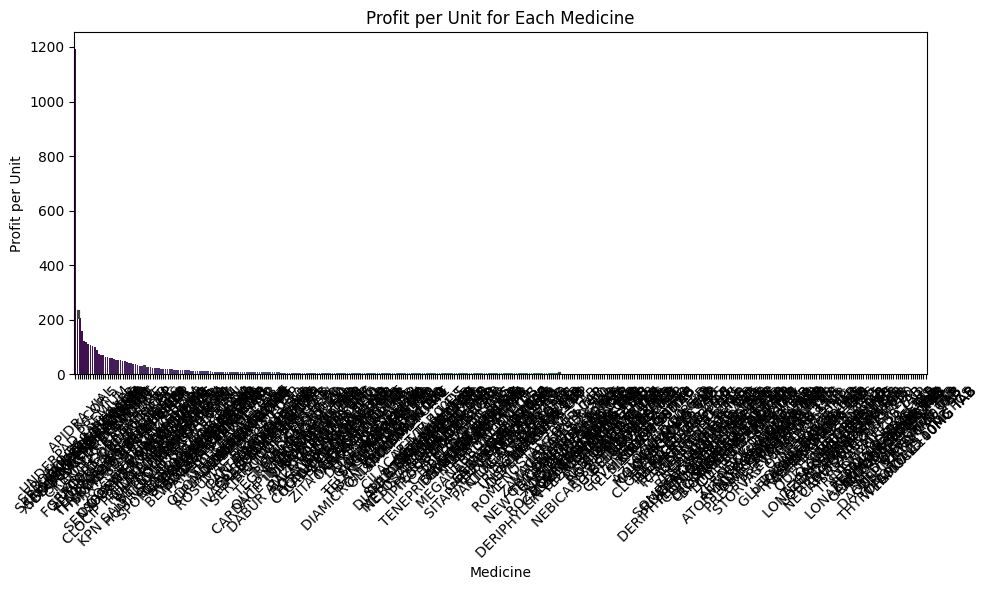

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(data=sorted_profit_table, x='Product', y='profit', palette='viridis')

plt.xlabel('Medicine')
plt.ylabel('Profit per Unit')
plt.title('Profit per Unit for Each Medicine')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


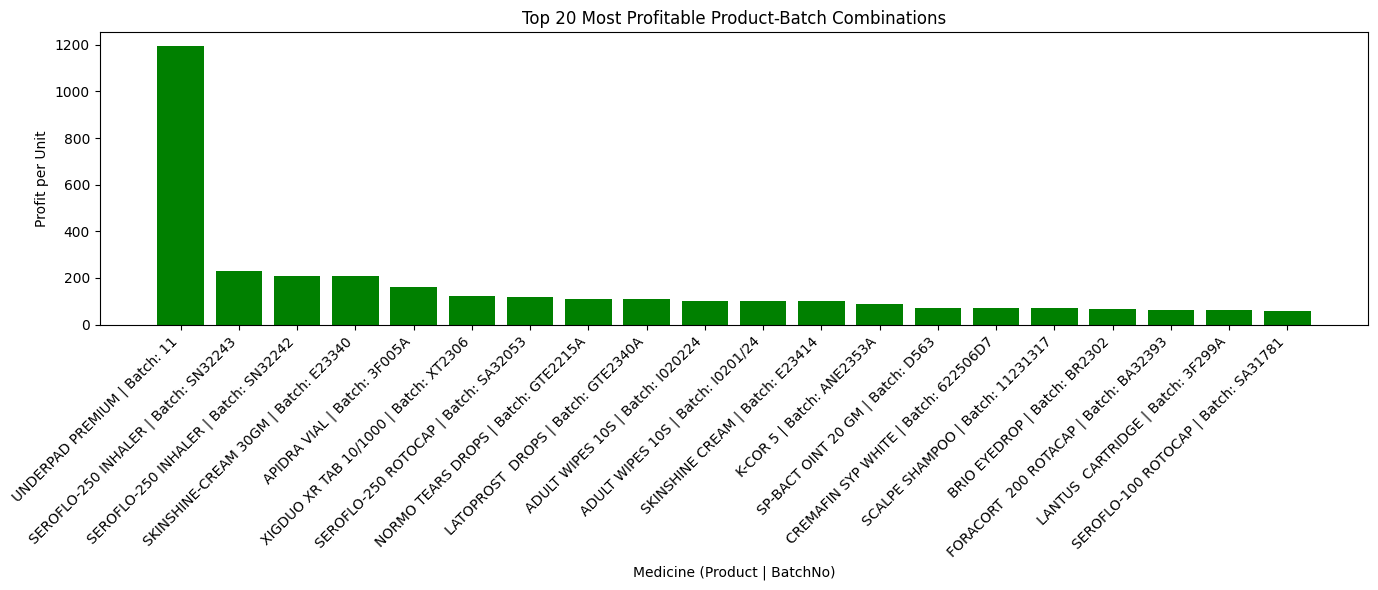

In [ ]:
# Top 20 most profitable Product-Batch combinations
top_n = sorted_profit_table.sort_values(by='profit', ascending=False).head(20)

# Combine Product and BatchNo for labeling
top_n['label'] = top_n['Product'] + ' | Batch: ' + top_n['BatchNo'].astype(str)

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.bar(top_n['label'], top_n['profit'], color='green')
plt.xlabel('Medicine (Product | BatchNo)')
plt.ylabel('Profit per Unit')
plt.title('Top 20 Most Profitable Product-Batch Combinations')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



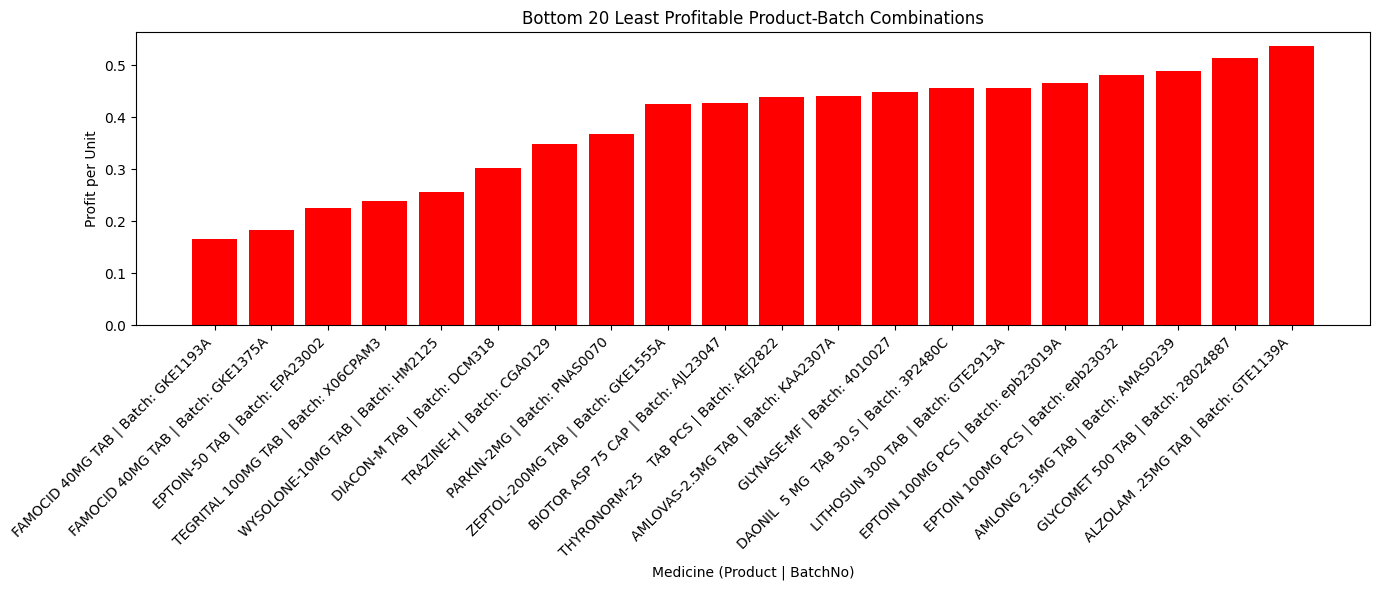

In [ ]:
# Bottom 20 least profitable Product-Batch combinations
bottom_n = sorted_profit_table.sort_values(by='profit').head(20)

# Create label combining Product and BatchNo
bottom_n['label'] = bottom_n['Product'] + ' | Batch: ' + bottom_n['BatchNo'].astype(str)

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.bar(bottom_n['label'], bottom_n['profit'], color='red')
plt.xlabel('Medicine (Product | BatchNo)')
plt.ylabel('Profit per Unit')
plt.title('Bottom 20 Least Profitable Product-Batch Combinations')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
# Filter rows where profit per unit is less than or equal to 50% of avg_purchase_unit_cost
loss_making_products = sorted_profit_table[
    sorted_profit_table['profit'] <= 0.5 * sorted_profit_table['avg_purchase_unit_cost']
]

loss_making_products.head()

,Product,BatchNo,avg_sales_unit_cost,avg_purchase_unit_cost,profit
342,SEROFLO-250 INHALER,SN32243,904.7624,674.1400,230.6224
341,SEROFLO-250 INHALER,SN32242,904.7624,695.4200,209.3424
16,APIDRA VIAL,3F005A,1396.2460,1237.0200,159.2260
422,XIGDUO XR TAB 10/1000,XT2306,515.1000,391.8900,123.2100
343,SEROFLO-250 ROTOCAP,SA32053,532.1228,413.1825,118.9403


In [ ]:
loss_making_products.shape

(376, 5)

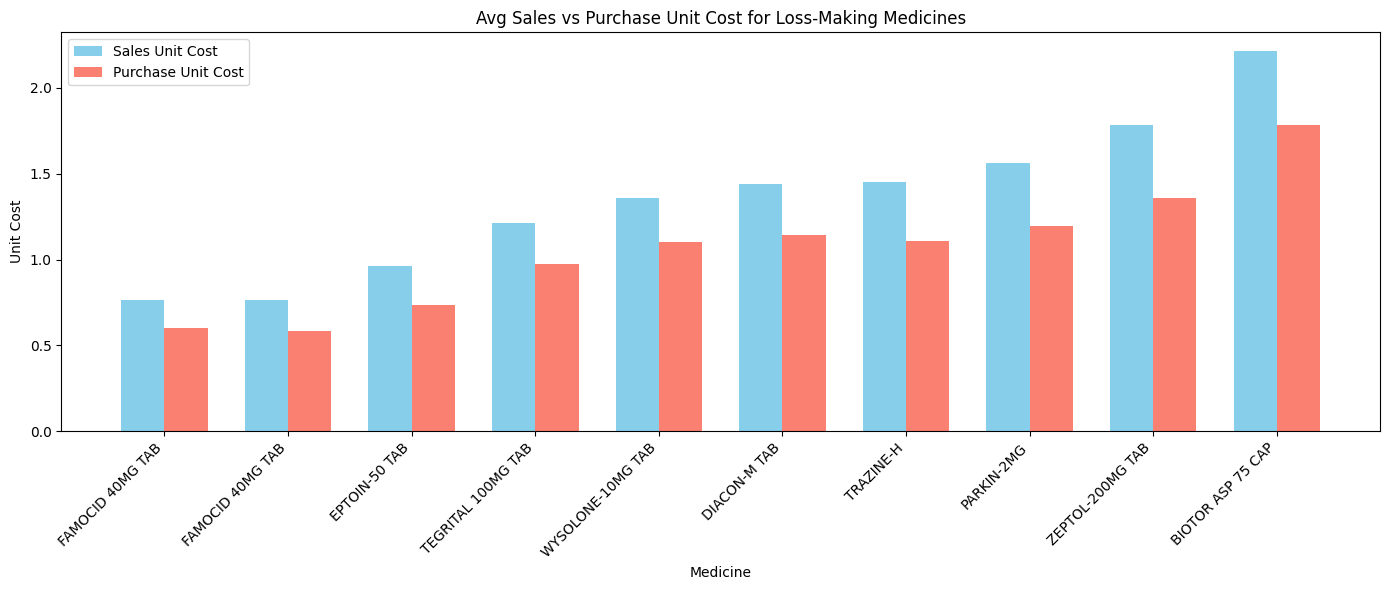

In [ ]:
#sales and purchase cost for loss making products.
import matplotlib.pyplot as plt
import numpy as np

# Use a small number of products (e.g., top 20 loss-makers) to keep the chart readable
loss_products = loss_making_products.sort_values(by='profit').head(10)

# Set position of bars on X-axis
x = np.arange(len(loss_products['Product']))

width = 0.35  # Width of each bar

# Plotting
plt.figure(figsize=(14, 6))

plt.bar(x - width/2, loss_products['avg_sales_unit_cost'], width, label='Sales Unit Cost', color='skyblue')
plt.bar(x + width/2, loss_products['avg_purchase_unit_cost'], width, label='Purchase Unit Cost', color='salmon')

plt.xlabel('Medicine')
plt.ylabel('Unit Cost')
plt.title('Avg Sales vs Purchase Unit Cost for Loss-Making Medicines')
plt.xticks(x, loss_products['Product'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
purchase_data[purchase_data['Product'] == 'UNDERPAD PREMIUM']

,Product,A/cDate,BillDat,Supplier,BatchNo,Expiry,Qty,Total,UnitCost
3221,UNDERPAD PREMIUM,04-04-2024,01-04-2024,MED-CARE SURGICALS,11,31-12-2028,5,850.01,170.002000
3222,UNDERPAD PREMIUM,29-04-2024,26-04-2024,MED-CARE SURGICALS,11,31-12-2028,3,510.01,170.003333


In [ ]:
#Products with 200% profit
top_profitable_products = sorted_profit_table[
    sorted_profit_table['profit'] >= 2*sorted_profit_table['avg_purchase_unit_cost']
]
top_profitable_products.shape

(8, 5)

In [ ]:
top_profitable_products

,Product,BatchNo,avg_sales_unit_cost,avg_purchase_unit_cost,profit
410,UNDERPAD PREMIUM,11,1364.000000,170.002667,1193.997333
355,SKINSHINE-CREAM 30GM,E23340,270.686000,63.010000,207.676000
358,SOREGEL OINT,C723012,69.923077,16.380000,53.543077
123,DUOBES 625,KT23038,19.314118,4.446875,14.867243
299,RABEPRAZOLE 20,T3147,10.023104,0.806389,9.216715
155,GLI-M TAB,SPA231561,11.687483,3.237900,8.449583
108,DEFLACE 6MG,IA573028,10.877778,2.833167,8.044611
49,CADMET-XR 50,AJL23046,7.313400,2.248800,5.064600


In [ ]:
# Merge to get supplier info from purchase_data
top_profitable_with_supplier = pd.merge(
    top_profitable_products[['Product', 'BatchNo']],
    purchase_data[['Product', 'BatchNo', 'Supplier']],
    on=['Product'],
    how='left'
)

# Drop duplicates if needed
top_supplier_list = top_profitable_with_supplier.drop_duplicates()

# Display
print(top_supplier_list)


                 Product  BatchNo_x  BatchNo_y                 Supplier
0       UNDERPAD PREMIUM         11         11       MED-CARE SURGICALS
2   SKINSHINE-CREAM 30GM     E23340     E23340            EMERALD DRUGS
3           SOREGEL OINT    C723012    C723012          NATIONAL PHARMA
5             DUOBES 625    KT23038    KT23038  RELIEF MEDICAL AGENCIES
7         RABEPRAZOLE 20      T3147      T3147  RELIEF MEDICAL AGENCIES
9              GLI-M TAB  SPA231561  SPA231561          M.M.ENTERPRISES
10           DEFLACE 6MG   IA573028   IA573028  RELIEF MEDICAL AGENCIES
11          CADMET-XR 50   AJL23046   AJL23046           RMS ASSOCIATES
15          CADMET-XR 50   AJL23046   AJL24004           RMS ASSOCIATES


## Note: At the earlier i took only medicined based on their sales qty. Here am taking medicines based on the profit per unit

Now Find the profitable medicines based on the total profit (not the profit per unit cost)

In [ ]:
# Step 1: Merge per-unit profit into sales_data using Product and BatchNo
sales_with_profit = pd.merge(
    sales_data,
    sorted_profit_table[['Product', 'BatchNo', 'profit']],

)

# Step 2: Calculate total profit for each row
sales_with_profit['total_profit'] = sales_with_profit['Qty'] * sales_with_profit['profit']

# Step 3: Group by Product and BatchNo to get total profit per combination
total_profit_by_batch = sales_with_profit.groupby(['Product', 'BatchNo'], as_index=False)['total_profit'].sum()

# Display result
total_profit_by_batch


,Product,BatchNo,total_profit
0,ACENOMAC 2 MG,FNV02305A,131.435714
1,ACIVIR 400DT,4SN0095,144.370400
2,ACIVIR 400DT,4SN0100,79.528533
3,ADULT WIPES 10S,I0201/24,412.493333
4,ADULT WIPES 10S,I020224,309.375000
...,...,...,...
430,ZIEPAN DSR,GC230360,1983.888720
431,ZITA MET 20/1000 TAB,50230075,156.483213
432,ZOLFRESH 10MG TAB,ZLA23032,42.032760
433,ZONISEP-50MG CAP,GKE1789A,55.446667


In [ ]:
sorted_profit_table[sorted_profit_table['Product'] == 'ACENOMAC 2 MG']

,Product,BatchNo,avg_sales_unit_cost,avg_purchase_unit_cost,profit
0,ACENOMAC 2 MG,FNV02305A,12.189,9.560286,2.628714


In [ ]:
sales_data[(sales_data['Product'] == 'ACENOMAC 2 MG') & (sales_data['BatchNo'] == 'FNV02305A')]


,Date,Product,BatchNo,Expiry Date,Qty,Total,YearMonth,UnitCost
161,2024-02-26,ACENOMAC 2 MG,FNV02305A,31-07-2025,20,243.78,2024-02,12.189
162,2024-03-27,ACENOMAC 2 MG,FNV02305A,31-07-2025,30,365.67,2024-03,12.189


In [ ]:
2.628714*50

131.4357

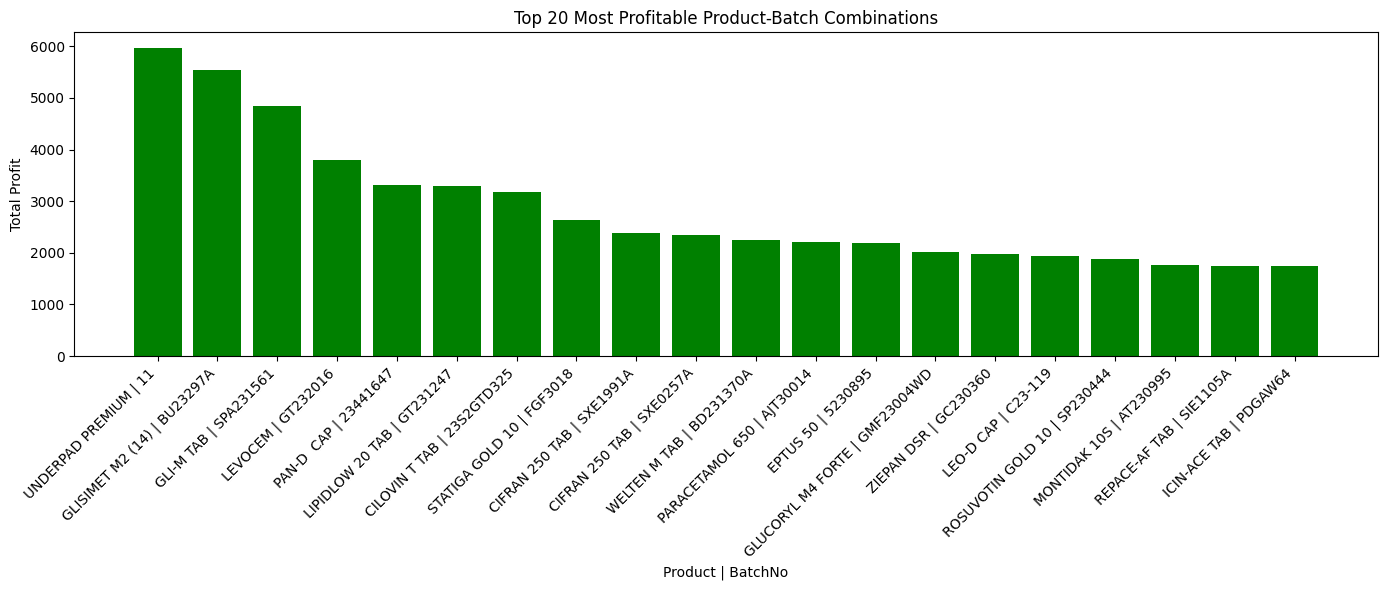

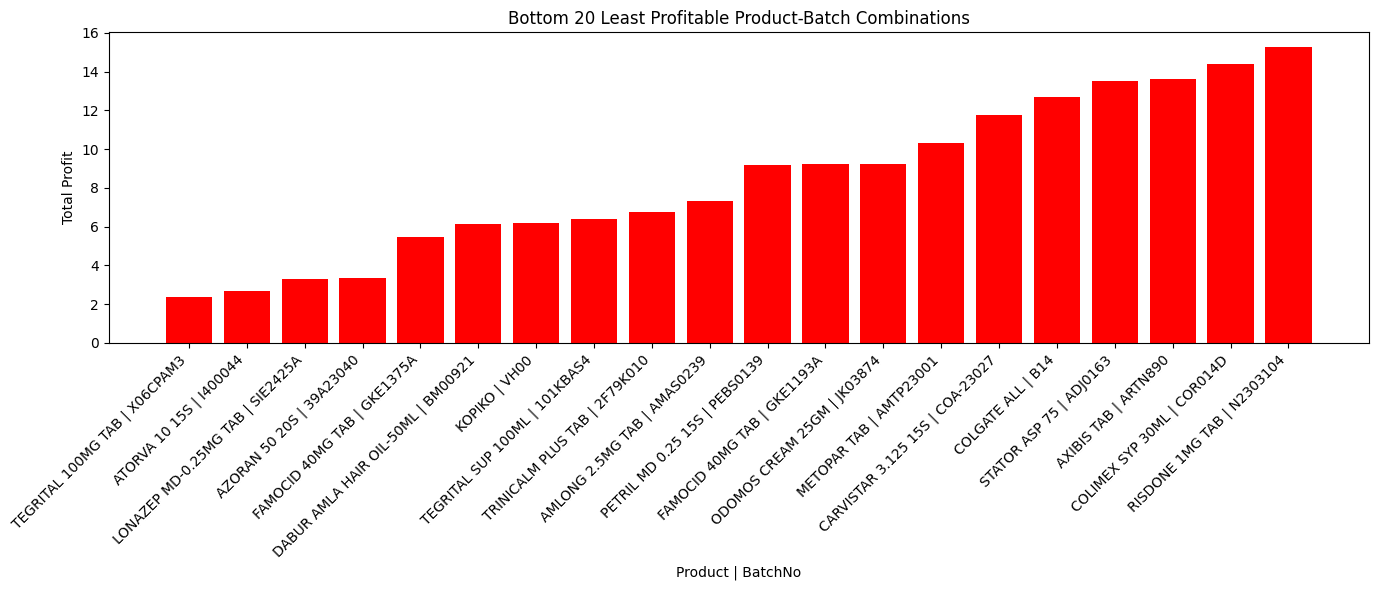

In [ ]:
import matplotlib.pyplot as plt

# Create a label combining Product and BatchNo
total_profit_by_batch['label'] = total_profit_by_batch['Product'] + ' | ' + total_profit_by_batch['BatchNo'].astype(str)

# Top 20 profitable
top_20 = total_profit_by_batch.sort_values(by='total_profit', ascending=False).head(20)

plt.figure(figsize=(14, 6))
plt.bar(top_20['label'], top_20['total_profit'], color='green')
plt.title('Top 20 Most Profitable Product-Batch Combinations')
plt.xlabel('Product | BatchNo')
plt.ylabel('Total Profit')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Bottom 20 profitable
bottom_20 = total_profit_by_batch.sort_values(by='total_profit').head(20)

plt.figure(figsize=(14, 6))
plt.bar(bottom_20['label'], bottom_20['total_profit'], color='red')
plt.title('Bottom 20 Least Profitable Product-Batch Combinations')
plt.xlabel('Product | BatchNo')
plt.ylabel('Total Profit')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Note:
UnitCost based profit is the most and least profitable products.
But Batch Based Total profit is the least and most profitable product list for this duration.

In [ ]:
# Aggregate total Qty purchased and sold by Product and BatchNo
purchase_qty = purchase_data.groupby(['Product', 'BatchNo'])['Qty'].sum().reset_index(name='total_purchased_qty')
sales_qty = sales_data.groupby(['Product', 'BatchNo'])['Qty'].sum().reset_index(name='total_sold_qty')

# Merge to get current stock
stock_status = pd.merge(purchase_qty, sales_qty, on=['Product', 'BatchNo'], how='left')
stock_status['total_sold_qty'] = stock_status['total_sold_qty'].fillna(0)
stock_status['current_stock'] = stock_status['total_purchased_qty'] - stock_status['total_sold_qty']


In [ ]:
# Step 1: Aggregate purchased and sold quantity by Product and BatchNo
purchase_qty = purchase_data.groupby(['Product', 'BatchNo'])['Qty'].sum().reset_index(name='total_purchased_qty')
sales_qty = sales_data.groupby(['Product', 'BatchNo'])['Qty'].sum().reset_index(name='total_sold_qty')

# Step 2: Merge using INNER JOIN to only keep common Product + BatchNo
stock_status = pd.merge(purchase_qty, sales_qty, on=['Product', 'BatchNo'], how='inner')


In [ ]:
stock_status

,Product,BatchNo,total_purchased_qty,total_sold_qty
0,ACENOMAC 2 MG,FNV02305A,70,50
1,ACIVIR 400DT,4SN0095,20,40
2,ACIVIR 400DT,4SN0100,30,20
3,ADULT WIPES 10S,I0201/24,3,4
4,ADULT WIPES 10S,I020224,4,3
...,...,...,...,...
430,ZIEPAN DSR,GC230360,160,396
431,ZITA MET 20/1000 TAB,50230075,60,30
432,ZOLFRESH 10MG TAB,ZLA23032,120,15
433,ZONISEP-50MG CAP,GKE1789A,30,20


In [ ]:
#inventory data
inventory_data = pd.read_csv('/content/sorted_inventory.csv')
inventory_data.head()

,Slno,Product,Qty,Rate,OrgVal,Unnamed: 5
0,1.0,4-QUIN LOT EYE DROP,2.0,200.00,400.00,NaN
1,2.0,4-QUIN-DROPS,2.0,156.00,312.00,NaN
2,3.0,A TO Z NS DROPS,2.0,70.50,141.00,NaN
3,4.0,A TO Z NS+,58.0,10.33,599.31,NaN
4,5.0,AB FLO CAP 15'S,45.0,16.44,739.80,NaN


In [ ]:
# Step 1: Clean and standardize Product names
stock_status['Product'] = stock_status['Product'].str.strip().str.upper()
inventory_data['Product'] = inventory_data['Product'].str.strip().str.upper()

# Step 2: Merge final stock (Qty) from inventory_data
stock_status = pd.merge(
    stock_status.drop(columns=['current_stock'], errors='ignore'),  # remove old if exists
    inventory_data[['Product', 'Qty']].rename(columns={'Qty': 'current_stock'}),
    on='Product',
    how='left'  # keep only those products present in stock_status
)


In [ ]:
stock_status

,Product,BatchNo,total_purchased_qty,total_sold_qty,current_stock
0,ACENOMAC 2 MG,FNV02305A,70,50,60.0
1,ACIVIR 400DT,4SN0095,20,40,2.0
2,ACIVIR 400DT,4SN0100,30,20,2.0
3,ADULT WIPES 10S,I0201/24,3,4,4.0
4,ADULT WIPES 10S,I020224,4,3,4.0
...,...,...,...,...,...
430,ZIEPAN DSR,GC230360,160,396,132.0
431,ZITA MET 20/1000 TAB,50230075,60,30,0.0
432,ZOLFRESH 10MG TAB,ZLA23032,120,15,49.0
433,ZONISEP-50MG CAP,GKE1789A,30,20,40.0


In [ ]:
stock_status['initial_stock'] = stock_status['current_stock']-stock_status['total_purchased_qty']+stock_status['total_sold_qty']
stock_status

,Product,BatchNo,total_purchased_qty,total_sold_qty,current_stock,initial_stock
0,ACENOMAC 2 MG,FNV02305A,70,50,60.0,40.0
1,ACIVIR 400DT,4SN0095,20,40,2.0,22.0
2,ACIVIR 400DT,4SN0100,30,20,2.0,-8.0
3,ADULT WIPES 10S,I0201/24,3,4,4.0,5.0
4,ADULT WIPES 10S,I020224,4,3,4.0,3.0
...,...,...,...,...,...,...
430,ZIEPAN DSR,GC230360,160,396,132.0,368.0
431,ZITA MET 20/1000 TAB,50230075,60,30,0.0,-30.0
432,ZOLFRESH 10MG TAB,ZLA23032,120,15,49.0,-56.0
433,ZONISEP-50MG CAP,GKE1789A,30,20,40.0,30.0


In [ ]:
# You can define a threshold, say 10 units
stock_status['stock_status'] = stock_status['current_stock'].apply(
    lambda x: 'Out of Stock' if x <= 0 else ('Low Stock' if x <= 10 else 'Sufficient')
)
stock_status

,Product,BatchNo,total_purchased_qty,total_sold_qty,current_stock,initial_stock,stock_status
0,ACENOMAC 2 MG,FNV02305A,70,50,60.0,40.0,Sufficient
1,ACIVIR 400DT,4SN0095,20,40,2.0,22.0,Low Stock
2,ACIVIR 400DT,4SN0100,30,20,2.0,-8.0,Low Stock
3,ADULT WIPES 10S,I0201/24,3,4,4.0,5.0,Low Stock
4,ADULT WIPES 10S,I020224,4,3,4.0,3.0,Low Stock
...,...,...,...,...,...,...,...
430,ZIEPAN DSR,GC230360,160,396,132.0,368.0,Sufficient
431,ZITA MET 20/1000 TAB,50230075,60,30,0.0,-30.0,Out of Stock
432,ZOLFRESH 10MG TAB,ZLA23032,120,15,49.0,-56.0,Sufficient
433,ZONISEP-50MG CAP,GKE1789A,30,20,40.0,30.0,Sufficient


In [ ]:
at_risk_medicines = stock_status[stock_status['stock_status'] != 'Sufficient']
at_risk_medicines.sort_values(by='current_stock')


,Product,BatchNo,total_purchased_qty,total_sold_qty,current_stock,initial_stock,stock_status
431,ZITA MET 20/1000 TAB,50230075,60,30,0.0,-30.0,Out of Stock
83,CODISTAR- SYP,Q2AIW008,2,1,1.0,0.0,Low Stock
198,LATOPROST DROPS,GTE2340A,1,2,1.0,2.0,Low Stock
212,LOBATE-CREAM 30GM,LD004,2,1,1.0,0.0,Low Stock
336,SCALPE SHAMPOO,11231317,1,1,1.0,1.0,Low Stock
...,...,...,...,...,...,...,...
190,K-COR 5,ANE2353A,3,11,9.0,17.0,Low Stock
400,TISSUE PAPER,BUTTERFLY,5,1,9.0,5.0,Low Stock
19,ARKAMIN-H,AR0223002,30,30,10.0,10.0,Low Stock
182,ILOSURE 4 TAB,GKE0978A,20,140,10.0,130.0,Low Stock


## Sales Forcasting

In [ ]:


monthly_sales = sales_data.groupby(['Product', 'BatchNo', 'YearMonth'])['Qty'].sum().reset_index()
avg_monthly_demand = monthly_sales.groupby(['Product', 'BatchNo'])['Qty'].mean().reset_index(name='avg_monthly_qty')

# Merge with current stock to get how many months stock can last
forecast_df = pd.merge(stock_status, avg_monthly_demand, on=['Product', 'BatchNo'], how='left')
forecast_df['months_of_stock_left'] = forecast_df['current_stock'] / forecast_df['avg_monthly_qty']


In [ ]:
forecast_df

,Product,BatchNo,total_purchased_qty,total_sold_qty,current_stock,initial_stock,stock_status,avg_monthly_qty,months_of_stock_left
0,ACENOMAC 2 MG,FNV02305A,70,50,60.0,40.0,Sufficient,25.000000,2.400000
1,ACIVIR 400DT,4SN0095,20,40,2.0,22.0,Low Stock,40.000000,0.050000
2,ACIVIR 400DT,4SN0100,30,20,2.0,-8.0,Low Stock,20.000000,0.100000
3,ADULT WIPES 10S,I0201/24,3,4,4.0,5.0,Low Stock,4.000000,1.000000
4,ADULT WIPES 10S,I020224,4,3,4.0,3.0,Low Stock,3.000000,1.333333
...,...,...,...,...,...,...,...,...,...
430,ZIEPAN DSR,GC230360,160,396,132.0,368.0,Sufficient,79.200000,1.666667
431,ZITA MET 20/1000 TAB,50230075,60,30,0.0,-30.0,Out of Stock,30.000000,0.000000
432,ZOLFRESH 10MG TAB,ZLA23032,120,15,49.0,-56.0,Sufficient,15.000000,3.266667
433,ZONISEP-50MG CAP,GKE1789A,30,20,40.0,30.0,Sufficient,20.000000,2.000000


## Finding ROP

In [ ]:
# Step 1: Filter sales_data for only common products
# Ensure consistency in column formatting
common_products['Product'] = common_products['Product'].str.strip().str.upper()
sales_data['Product'] = sales_data['Product'].str.strip().str.upper()

# Filter sales_data
sales_common = sales_data[sales_data['Product'].isin(common_products['Product'])]


In [ ]:
#Step 2: Convert Date and get daily sales per product
sales_common['Date'] = pd.to_datetime(sales_common['Date'])

# Group by Product and Date to get daily sales
daily_sales = sales_common.groupby(['Product', 'Date'])['Qty'].sum().reset_index()


<ipython-input-51-5ff0a6864ba7>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales_common['Date'] = pd.to_datetime(sales_common['Date'])


In [ ]:
#Step 3: Calculate Average Daily Usage
avg_daily_usage = daily_sales.groupby('Product')['Qty'].mean().reset_index()
avg_daily_usage.rename(columns={'Qty': 'avg_daily_usage'}, inplace=True)


In [ ]:
#Step 4: Set Lead Time & Calculate ROP
lead_time_days = 1  # or adjust if you have product-wise lead times

avg_daily_usage['ROP'] = avg_daily_usage['avg_daily_usage'] * lead_time_days
avg_daily_usage


,Product,avg_daily_usage,ROP
0,ACENOMAC 2 MG,30.000000,30.000000
1,ACIVIR 400DT,11.230769,11.230769
2,ADULT WIPES 10S,4.000000,4.000000
3,AGPENTIN-100MG,12.000000,12.000000
4,ALPRAX 0.25MG TAB,11.736842,11.736842
...,...,...,...
393,ZIEPAN DSR,18.705882,18.705882
394,ZITA MET 20/1000 TAB,21.428571,21.428571
395,ZOLFRESH 10MG TAB,15.085714,15.085714
396,ZONISEP-50MG CAP,27.500000,27.500000


In [ ]:
#Step 5: (Optional) Compare with current stock from inventory_data
# Prepare inventory data
inventory_data['Product'] = inventory_data['Product'].str.strip().str.upper()

# Merge with current stock
rop_check = pd.merge(avg_daily_usage, inventory_data[['Product', 'Qty']], on='Product', how='left')
rop_check.rename(columns={'Qty': 'current_stock'}, inplace=True)

# Flag items needing reorder
rop_check['Reorder_Needed'] = rop_check['current_stock'] < rop_check['ROP']

# View results
rop_check_sorted = rop_check.sort_values(by='ROP', ascending=False)
rop_check_sorted


,Product,avg_daily_usage,ROP,current_stock,Reorder_Needed
118,EPTOIN-50 TAB,150.000000,150.000000,300.0,False
59,CIFRAN 250 TAB,106.044776,106.044776,580.0,False
218,"NEUROBION FORTE 30,S",90.368421,90.368421,616.0,False
93,"DAONIL 5 MG TAB 30,S",81.198020,81.198020,689.0,False
359,THYRONORM-25 TAB PCS,71.179487,71.179487,436.0,False
...,...,...,...,...,...
320,SKINLITE CREAM 15GM,1.000000,1.000000,2.0,False
43,BRIO EYEDROP,1.000000,1.000000,2.0,False
128,FLOJO EYE DROPS,1.000000,1.000000,2.0,False
129,FLOJO-KT DROP,1.000000,1.000000,1.0,False


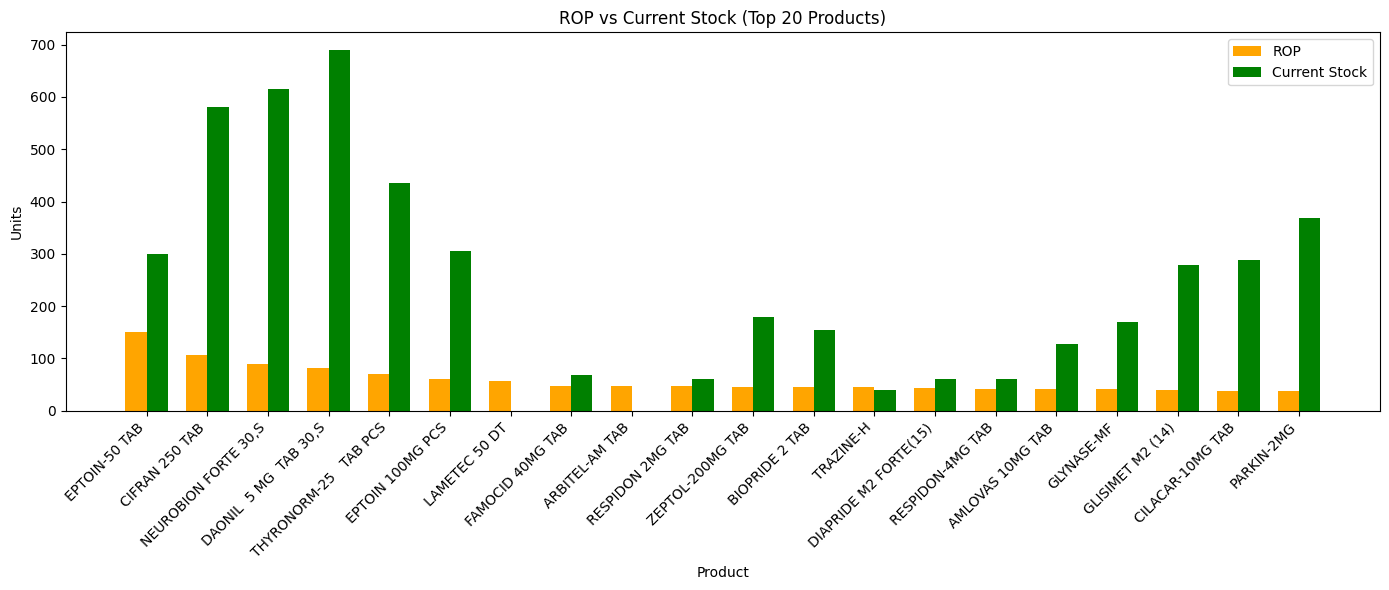

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Take top 20 for better readability
top_rop_check = rop_check_sorted.head(20)

# Bar plot setup
x = np.arange(len(top_rop_check['Product']))
width = 0.35

plt.figure(figsize=(14, 6))
plt.bar(x - width/2, top_rop_check['ROP'], width, label='ROP', color='orange')
plt.bar(x + width/2, top_rop_check['current_stock'], width, label='Current Stock', color='green')

plt.xlabel('Product')
plt.ylabel('Units')
plt.title('ROP vs Current Stock (Top 20 Products)')
plt.xticks(x, top_rop_check['Product'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()


## EOQ

In [ ]:
#Step 1: Filter sales_data for common_products
# Normalize strings
sales_data['Product'] = sales_data['Product'].str.strip().str.upper()
common_products['Product'] = common_products['Product'].str.strip().str.upper()

sales_common = sales_data[sales_data['Product'].isin(common_products['Product'])]


In [ ]:
#Step 2: Calculate Annual Demand (D)
sales_common['Date'] = pd.to_datetime(sales_common['Date'])

# Calculate demand per year
sales_common['Year'] = sales_common['Date'].dt.year
annual_demand = sales_common.groupby(['Product', 'Year'])['Qty'].sum().reset_index()

# Average annual demand per product
demand_per_product = annual_demand.groupby('Product')['Qty'].mean().reset_index()
demand_per_product.rename(columns={'Qty': 'annual_demand'}, inplace=True)


<ipython-input-57-05e84aac6b4b>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales_common['Date'] = pd.to_datetime(sales_common['Date'])
<ipython-input-57-05e84aac6b4b>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales_common['Year'] = sales_common['Date'].dt.year


In [ ]:
#Step 3: Estimate Holding Cost and Calculate EOQ
# Get average UnitCost for each product
purchase_data['Product'] = purchase_data['Product'].str.strip().str.upper()
avg_unit_cost = purchase_data.groupby('Product')['UnitCost'].mean().reset_index()

# Merge with demand
eoq_data = pd.merge(demand_per_product, avg_unit_cost, on='Product', how='inner')

# Parameters
ordering_cost = 100  # S
eoq_data['holding_cost'] = 0.10 * eoq_data['UnitCost']  # H = 10% of UnitCost

# EOQ Calculation
eoq_data['EOQ'] = ((2 * eoq_data['annual_demand'] * ordering_cost) / eoq_data['holding_cost']) ** 0.5


In [ ]:
eoq_data

,Product,annual_demand,UnitCost,holding_cost,EOQ
0,ACENOMAC 2 MG,90.0,9.560143,0.956014,137.215781
1,ACIVIR 400DT,73.0,11.810917,1.181092,111.182037
2,ADULT WIPES 10S,6.0,379.995833,37.999583,5.619546
3,AGPENTIN-100MG,60.0,7.268333,0.726833,128.491147
4,ALPRAX 0.25MG TAB,111.5,1.792000,0.179200,352.763326
...,...,...,...,...,...
393,ZIEPAN DSR,318.0,4.323857,0.432386,383.524303
394,ZITA MET 20/1000 TAB,75.0,16.237889,1.623789,96.112715
395,ZOLFRESH 10MG TAB,264.0,7.395500,0.739550,267.197992
396,ZONISEP-50MG CAP,55.0,8.447667,0.844767,114.111117


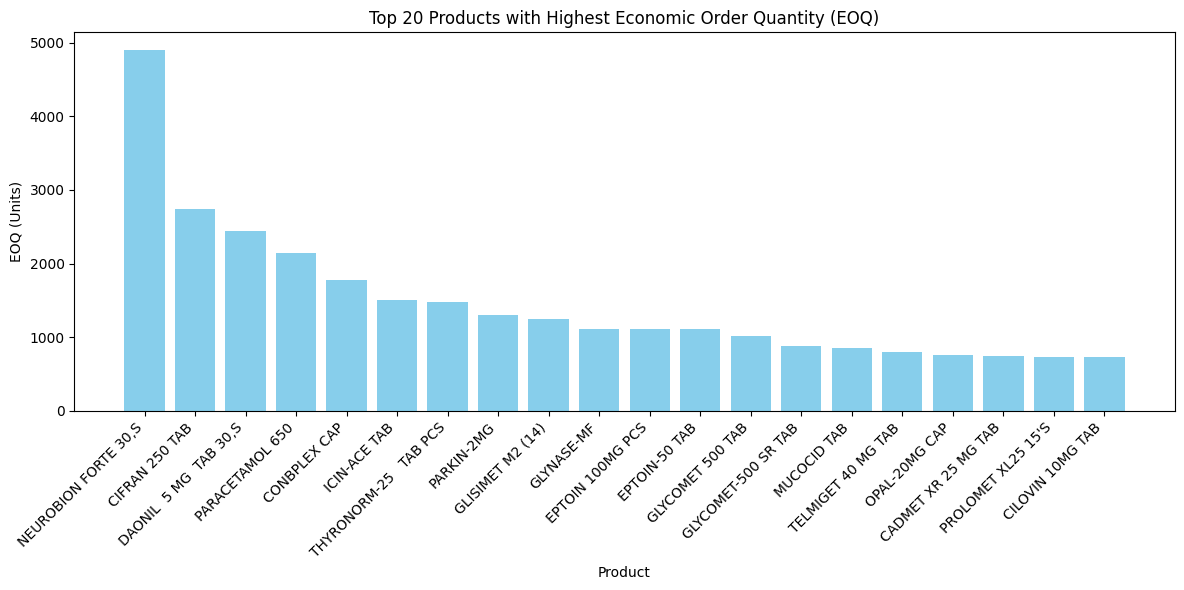

In [ ]:
import matplotlib.pyplot as plt

# Sort top 20 products with highest EOQ for visibility
top_eoq = eoq_data.sort_values(by='EOQ', ascending=False).head(20)

plt.figure(figsize=(12, 6))
plt.bar(top_eoq['Product'], top_eoq['EOQ'], color='skyblue')
plt.xlabel('Product')
plt.ylabel('EOQ (Units)')
plt.title('Top 20 Products with Highest Economic Order Quantity (EOQ)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## Sales Forcast

In [ ]:
common_sales = sales_data[sales_data['Product'].isin(common_products['Product'])]
common_sales['Date'] = pd.to_datetime(common_sales['Date'])  # Ensure datetime


<ipython-input-61-682c08fc2821>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  common_sales['Date'] = pd.to_datetime(common_sales['Date'])  # Ensure datetime


In [ ]:
# Group by Product and Month
common_sales['YearMonth'] = common_sales['Date'].dt.to_period('M').astype(str)

monthly_sales = (
    common_sales
    .groupby(['Product', 'YearMonth'])['Qty']
    .sum()
    .reset_index()
)
monthly_sales

<ipython-input-63-e5338ace3998>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  common_sales['YearMonth'] = common_sales['Date'].dt.to_period('M').astype(str)


,Product,YearMonth,Qty
0,ACENOMAC 2 MG,2023-10,30
1,ACENOMAC 2 MG,2023-11,30
2,ACENOMAC 2 MG,2023-12,20
3,ACENOMAC 2 MG,2024-01,40
4,ACENOMAC 2 MG,2024-02,30
...,...,...,...
2082,ZORYL MF 1,2023-11,96
2083,ZORYL MF 1,2023-12,75
2084,ZORYL MF 1,2024-01,35
2085,ZORYL MF 1,2024-02,35


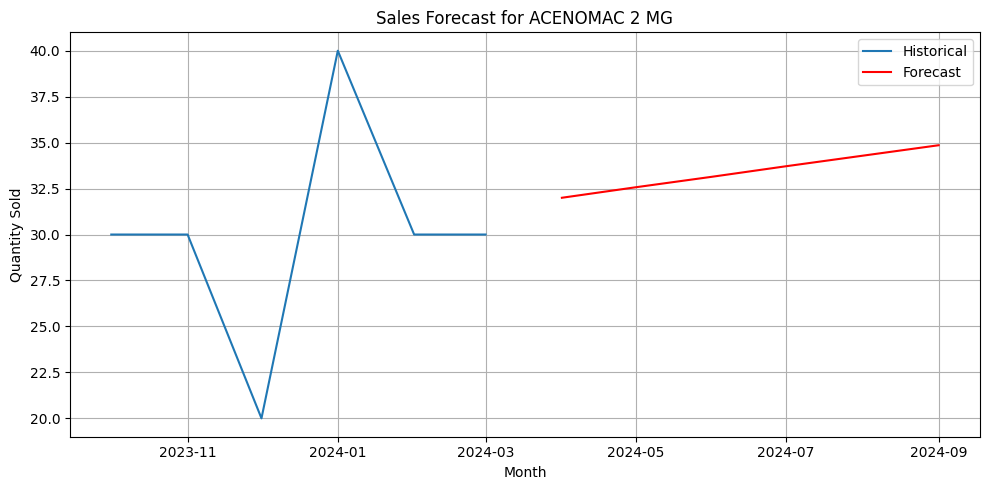

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Filter one product
product_name = 'ACENOMAC 2 MG'
product_sales = monthly_sales[monthly_sales['Product'] == product_name]
product_sales.set_index('YearMonth', inplace=True)
product_sales.index = pd.to_datetime(product_sales.index)
product_sales = product_sales.asfreq('MS')  # Monthly start frequency

# Forecast
model = ExponentialSmoothing(product_sales['Qty'], trend='add', seasonal=None)
fit = model.fit()
forecast = fit.forecast(6)  # Forecast next 6 months

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(product_sales.index, product_sales['Qty'], label='Historical')
plt.plot(forecast.index, forecast, label='Forecast', color='red')
plt.title(f"Sales Forecast for {product_name}")
plt.xlabel("Month")
plt.ylabel("Quantity Sold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
#top 5 products
top_20.head()

,Product,BatchNo,total_profit,label
410,UNDERPAD PREMIUM,11,5969.986667,UNDERPAD PREMIUM | 11
159,GLISIMET M2 (14),BU23297A,5542.398806,GLISIMET M2 (14) | BU23297A
155,GLI-M TAB,SPA231561,4833.161285,GLI-M TAB | SPA231561
201,LEVOCEM,GT232016,3793.951219,LEVOCEM | GT232016
270,PAN-D CAP,23441647,3311.175000,PAN-D CAP | 23441647


In [ ]:
top_5_products = top_20.head().Product.tolist()
top_5_products

['UNDERPAD PREMIUM', 'GLISIMET M2 (14)', 'GLI-M TAB', 'LEVOCEM', 'PAN-D  CAP']

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:1412: RuntimeWarning: divide by zero encountered in log
  aic = self.nobs * np.log(sse / self.nobs) + k * 2
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:1418: RuntimeWarning: invalid value encountered in scalar add
  aicc = aic + aicc_penalty
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:1419: RuntimeWarning: divide by zero encountered in log
  bic = self.nobs * np.log(sse / self.nobs) + k * np.log(self.nobs)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:1412: RuntimeWarning: divide by zero encountered in log
  aic = self.nobs * np.log(sse / self.nobs) + k * 2
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:1418: RuntimeWarning: invalid value encountered in scalar add
  aicc = aic + aicc_penalty
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:1419: RuntimeWarni

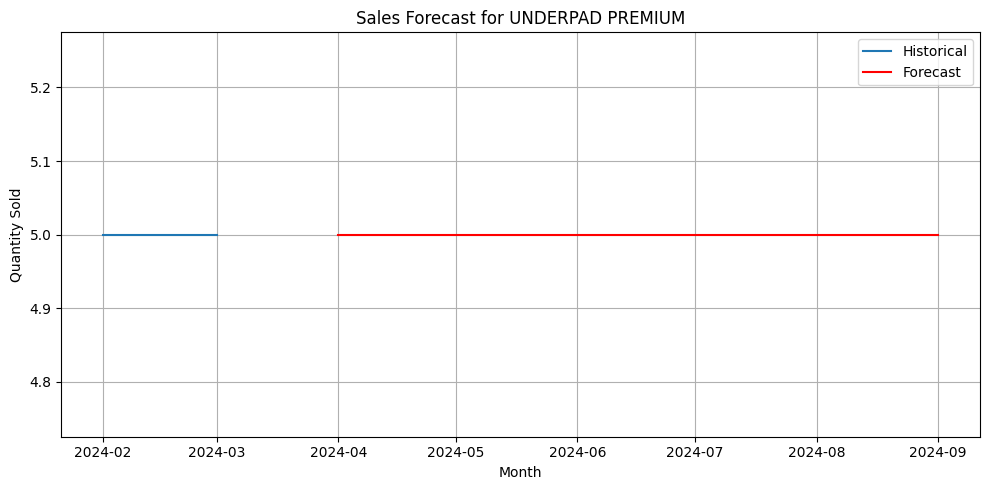

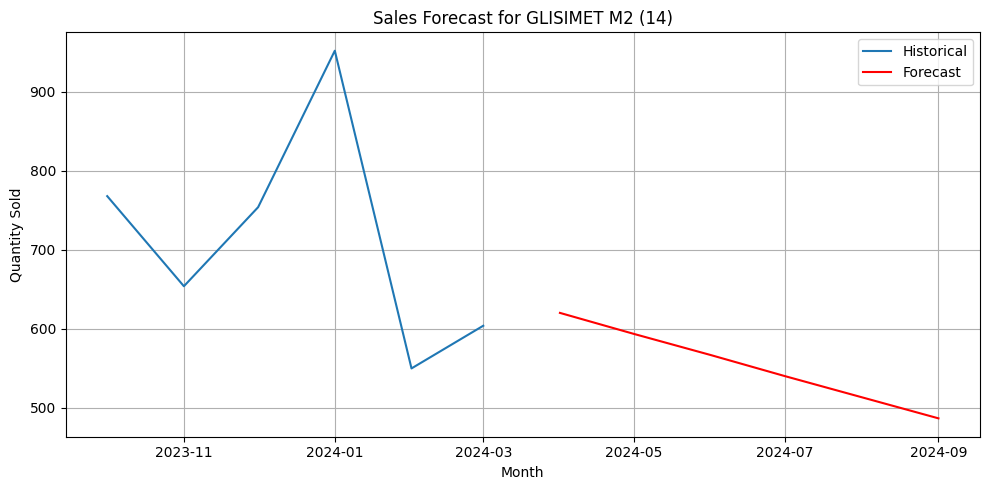

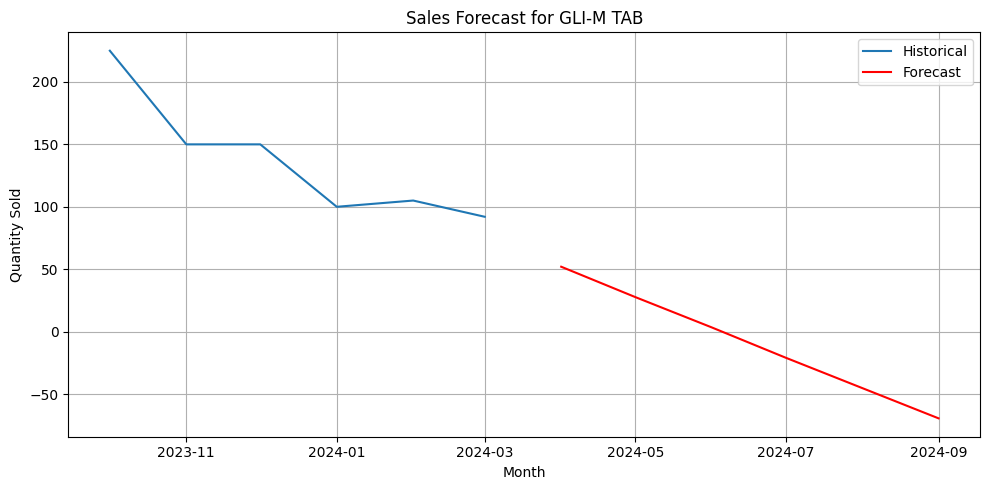

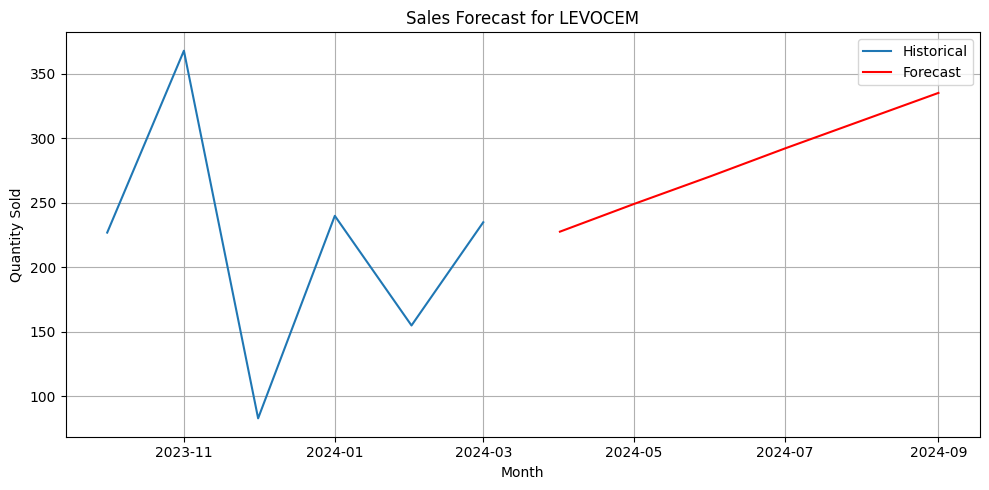

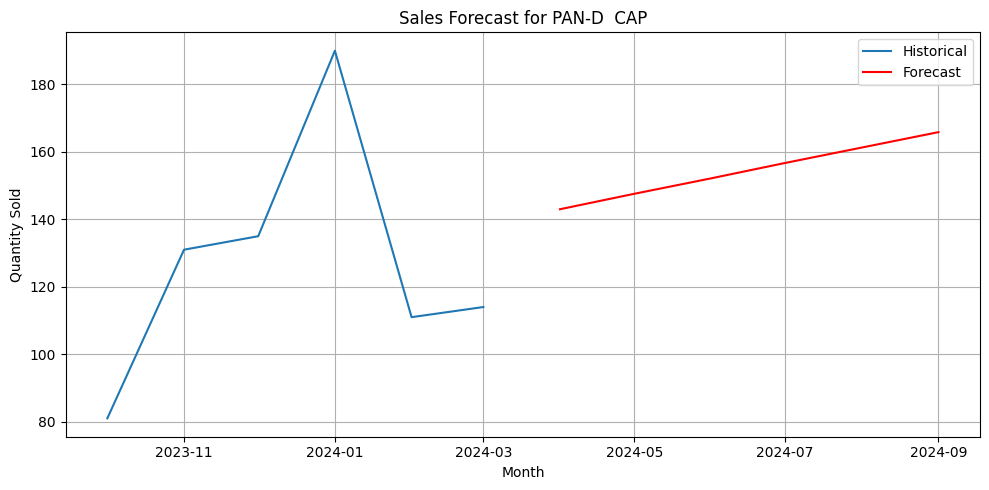

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
i=0
while i <5:
  # Filter one product
  product_name = top_5_products[i]
  i=i+1
  product_sales = monthly_sales[monthly_sales['Product'] == product_name]
  product_sales.set_index('YearMonth', inplace=True)
  product_sales.index = pd.to_datetime(product_sales.index)
  product_sales = product_sales.asfreq('MS')  # Monthly start frequency

  # Forecast
  model = ExponentialSmoothing(product_sales['Qty'], trend='add', seasonal=None)
  fit = model.fit()
  forecast = fit.forecast(6)  # Forecast next 6 months

  # Plot
  import matplotlib.pyplot as plt

  plt.figure(figsize=(10, 5))
  plt.plot(product_sales.index, product_sales['Qty'], label='Historical')
  plt.plot(forecast.index, forecast, label='Forecast', color='red')
  plt.title(f"Sales Forecast for {product_name}")
  plt.xlabel("Month")
  plt.ylabel("Quantity Sold")
  plt.legend()
  plt.grid(True)
  plt.tight_layout()
  plt.show()


In [ ]:
bottom_5_products = bottom_20.head().Product.tolist()
bottom_5_products

['TEGRITAL 100MG TAB',
 'ATORVA 10 15S',
 'LONAZEP MD-0.25MG TAB',
 'AZORAN 50 20S',
 'FAMOCID 40MG TAB']

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


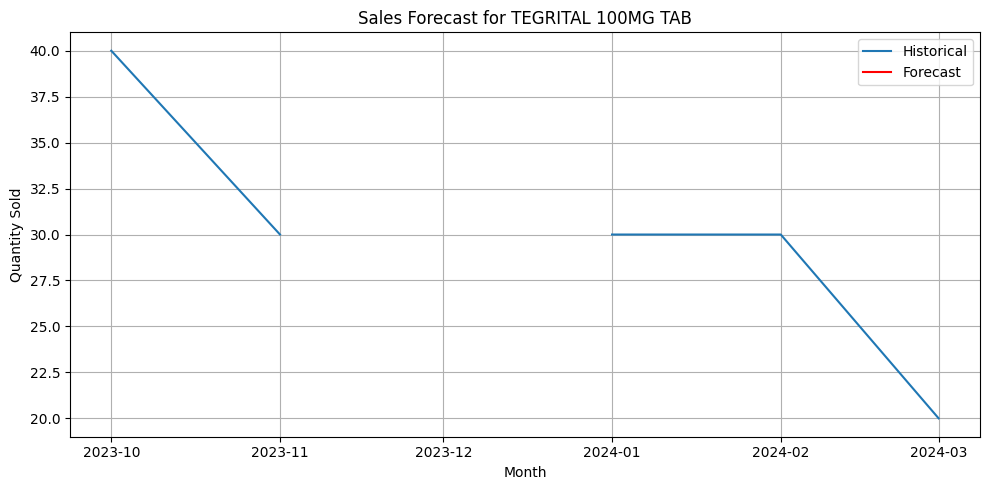

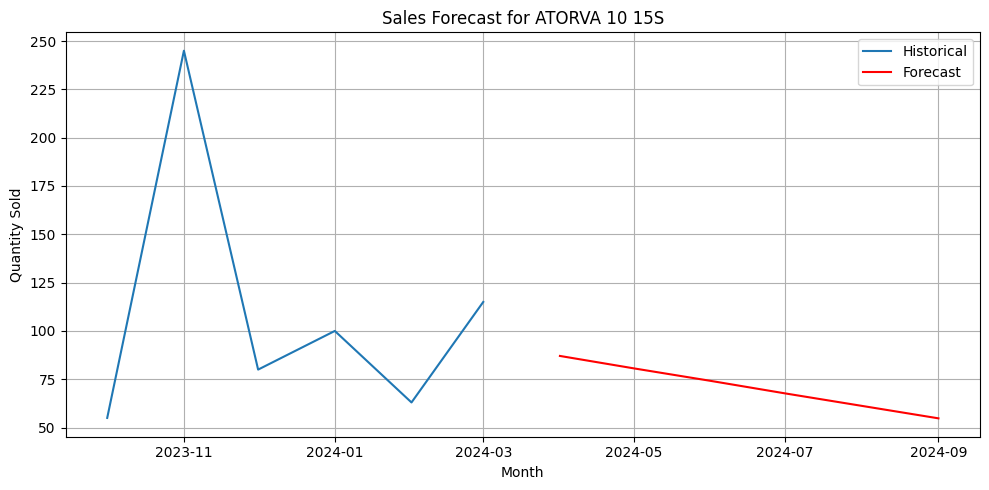

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


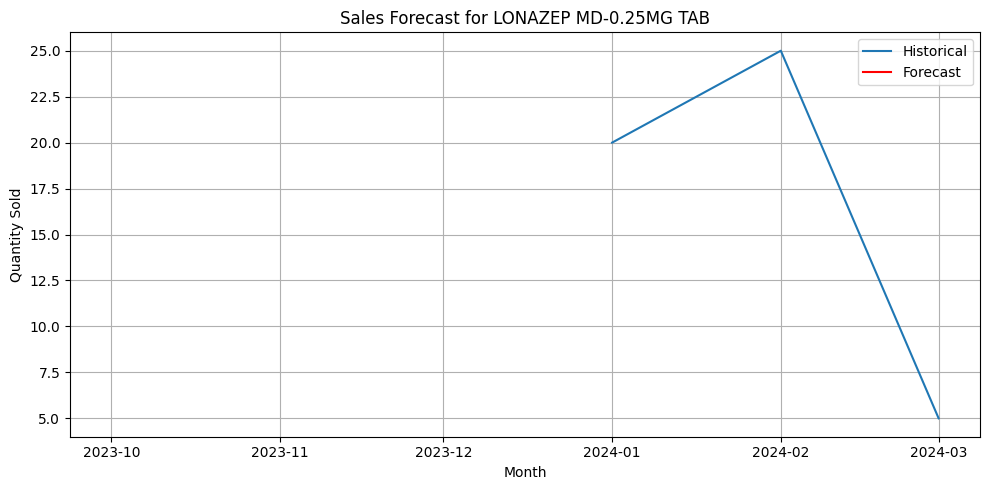

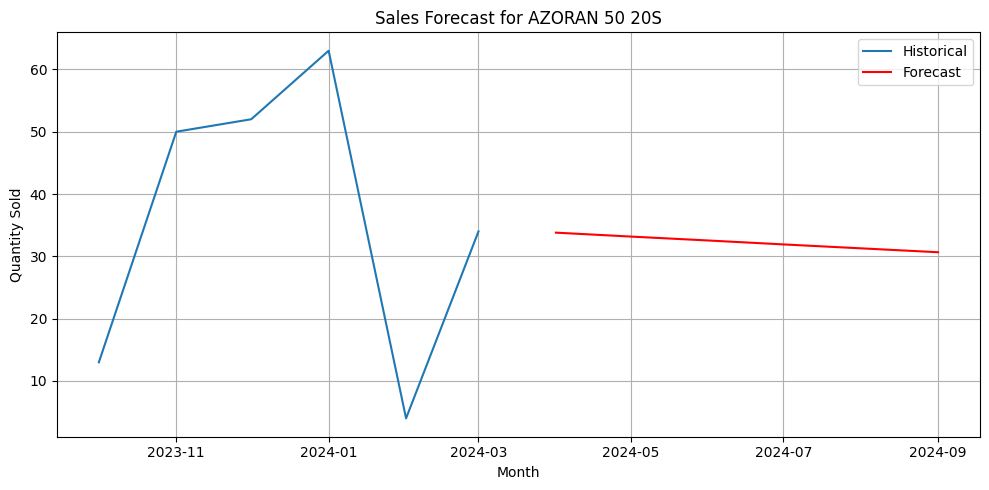

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


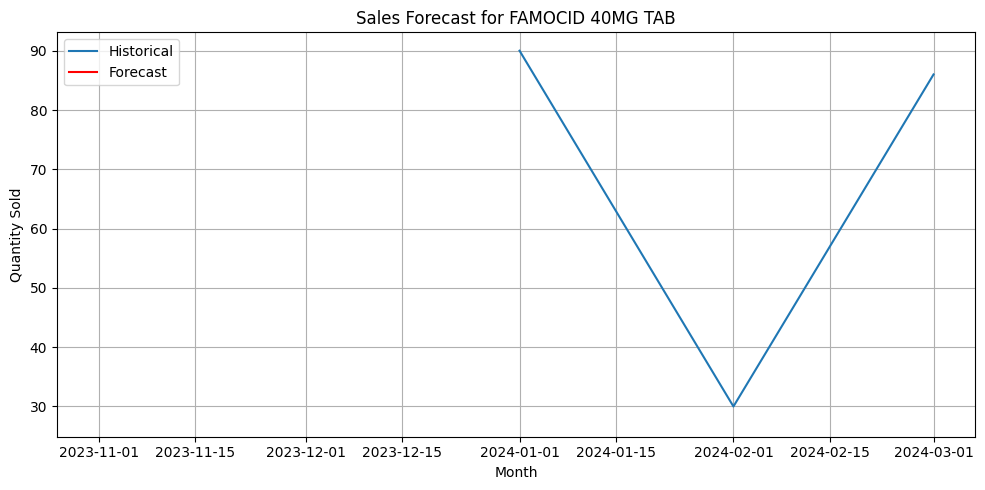

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
i=0
while i<5:
  # Filter one product
  product_name = bottom_5_products[i]
  i=i+1
  product_sales = monthly_sales[monthly_sales['Product'] == product_name]
  product_sales.set_index('YearMonth', inplace=True)
  product_sales.index = pd.to_datetime(product_sales.index)
  product_sales = product_sales.asfreq('MS')  # Monthly start frequency

  # Forecast
  model = ExponentialSmoothing(product_sales['Qty'], trend='add', seasonal=None)
  fit = model.fit()
  forecast = fit.forecast(6)  # Forecast next 6 months

  # Plot
  import matplotlib.pyplot as plt

  plt.figure(figsize=(10, 5))
  plt.plot(product_sales.index, product_sales['Qty'], label='Historical')
  plt.plot(forecast.index, forecast, label='Forecast', color='red')
  plt.title(f"Sales Forecast for {product_name}")
  plt.xlabel("Month")
  plt.ylabel("Quantity Sold")
  plt.legend()
  plt.grid(True)
  plt.tight_layout()
  plt.show()


In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import pandas as pd

# Ensure datetime format
sales_data['Date'] = pd.to_datetime(sales_data['Date'])

# Filter to common products
common_sales = sales_data[sales_data['Product'].isin(common_products['Product'])]

# Create YearMonth column
common_sales['YearMonth'] = common_sales['Date'].dt.to_period('M').astype(str)

# Group monthly
monthly_sales = (
    common_sales
    .groupby(['Product', 'YearMonth'])['Qty']
    .sum()
    .reset_index()
)

# Forecast storage
forecast_results = []

# Loop through each product and forecast
for product in monthly_sales['Product'].unique():
    product_data = monthly_sales[monthly_sales['Product'] == product].copy()
    product_data.set_index('YearMonth', inplace=True)
    product_data.index = pd.to_datetime(product_data.index)
    product_data = product_data.asfreq('MS')

    try:
        model = ExponentialSmoothing(product_data['Qty'], trend='add', seasonal=None)
        fit = model.fit()
        forecast = fit.forecast(3)  # next 3 months

        # Store forecasted values
        for date, qty in forecast.items():
            forecast_results.append({
                'Product': product,
                'ForecastMonth': date.strftime('%Y-%m'),
                'ForecastQty': round(qty)
            })

    except Exception as e:
        print(f"Skipped {product}: {e}")

# Convert results to DataFrame
forecast_df = pd.DataFrame(forecast_results)


<ipython-input-83-a7664fa65a74>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  common_sales['YearMonth'] = common_sales['Date'].dt.to_period('M').astype(str)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:918: 

Skipped ACIVIR 400DT: cannot convert float NaN to integer
Skipped ADULT WIPES 10S: cannot convert float NaN to integer
Skipped AMLOVAS 10MG TAB: cannot convert float NaN to integer
Skipped AMLOVAS-2.5MG TAB: cannot convert float NaN to integer
Skipped ANTOXID CAP: cannot convert float NaN to integer
Skipped ARBITEL-AM TAB: cannot convert float NaN to integer


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


Skipped ATAST 5 TAB: cannot convert float NaN to integer
Skipped AZULIX 3MF 15S: cannot convert float NaN to integer


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:1412: RuntimeWarning: divide by zero encountered in log
  aic = self.nobs * np.log(sse / self.nobs) + k * 2
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:1418: RuntimeWarning: invalid value encountered in scalar add
  aicc = aic + aicc_penalty
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:1419: RuntimeWarning: divide by zero encountered in log
  bic = self.nobs * np.log(sse / self.nobs) + k * np.log(self.nobs)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:1412: RuntimeWarning: divide by zero encountered in log
  aic = self.nobs * np.log(sse / self.nobs) + k * 2
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:1418: RuntimeW

...

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:1412: RuntimeWarning: divide by zero encountered in log
  aic = self.nobs * np.log(sse / self.nobs) + k * 2
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:1418: RuntimeWarning: invalid value encountered in scalar add
  aicc = aic + aicc_penalty
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:1419: RuntimeWarning: divide by zero encountered in log
  bic = self.nobs * np.log(sse / self.nobs) + k * np.log(self.nobs)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:1412: RuntimeWarning: divide

Skipped TENDIA M: cannot convert float NaN to integer
Skipped THYROCAL-D3: index 1 is out of bounds for axis 0 with size 1
Skipped THYRONORM-37.5 (100S): cannot convert float NaN to integer
Skipped TISSUE PAPER: cannot convert float NaN to integer
Skipped TRIGLIMIPREX 2 TAB: index 1 is out of bounds for axis 0 with size 1
Skipped TRIVEDON MR TAB: index 1 is out of bounds for axis 0 with size 1


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:1412: RuntimeWarning: divide by zero encountered in log
  aic = self.nobs * np.log(sse / self.nobs) + k * 2
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:1418: RuntimeWarning: invalid value encountered in scalar add
  aicc = aic + aicc_penalty
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:1419: RuntimeWarning: divide by zero encountered in log
  bic = self.nobs * np.log(sse / self.nobs) + k * np.log(self.nobs)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:1412: RuntimeWarning: divide by zero encountered in log
  aic = self.nobs * np.log(sse / self.nobs) + k * 2
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:1418: RuntimeWarning: invalid value encountered in scalar add
  aicc = aic + aicc_penalty
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:1419: RuntimeWarni

Skipped V-WASH 20 ML: cannot convert float NaN to integer
Skipped ZERODOL-100MG TAB: cannot convert float NaN to integer
Skipped ZONISEP-50MG CAP: cannot convert float NaN to integer


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:1412: RuntimeWarning: divide by zero encountered in log
  aic = self.nobs * np.log(sse / self.nobs) + k * 2
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:1418: RuntimeWarning: invalid value encountered in scalar add
  aicc = aic + aicc_penalty
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:1419: RuntimeWarning: divide by zero encountered in log
  bic = self.nobs * np.log(sse / self.nobs) + k * np.log(self.nobs)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:1412: RuntimeWarning: divide by zero encountered in log
  aic = self.nobs * np.log(sse / self.nobs) + k * 2
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:1418: RuntimeW

In [ ]:
forecast_df

,Product,ForecastMonth,ForecastQty
0,ACENOMAC 2 MG,2024-04,32
1,ACENOMAC 2 MG,2024-05,33
2,ACENOMAC 2 MG,2024-06,33
3,AGPENTIN-100MG,2024-04,30
4,AGPENTIN-100MG,2024-05,35
...,...,...,...
937,ZOLFRESH 10MG TAB,2024-05,47
938,ZOLFRESH 10MG TAB,2024-06,38
939,ZORYL MF 1,2024-04,64
940,ZORYL MF 1,2024-05,58


# Forcast based on moving **average**

In [ ]:
# Create a monthly sales table
common_sales['YearMonth'] = common_sales['Date'].dt.to_period('M').astype(str)
monthly_sales = (
    common_sales
    .groupby(['Product', 'YearMonth'])['Qty']
    .sum()
    .reset_index()
)

forecast_results_ma = []

for product in monthly_sales['Product'].unique():
    product_data = monthly_sales[monthly_sales['Product'] == product].copy()
    product_data.set_index('YearMonth', inplace=True)
    product_data.index = pd.to_datetime(product_data.index)
    product_data = product_data.asfreq('MS')

    try:
        # Take last 3 months average
        last_3_avg = product_data['Qty'].dropna().iloc[-3:].mean()
        for i in range(1, 4):
            forecast_date = product_data.index[-1] + pd.DateOffset(months=i)
            forecast_results_ma.append({
                'Product': product,
                'ForecastMonth': forecast_date.strftime('%Y-%m'),
                'ForecastQty': round(last_3_avg)
            })
    except Exception as e:
        print(f"Skipped {product}: {e}")

forecast_df_ma = pd.DataFrame(forecast_results_ma)


<ipython-input-85-c27819d80a48>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  common_sales['YearMonth'] = common_sales['Date'].dt.to_period('M').astype(str)


In [ ]:
forecast_df_ma

,Product,ForecastMonth,ForecastQty
0,ACENOMAC 2 MG,2024-04,33
1,ACENOMAC 2 MG,2024-05,33
2,ACENOMAC 2 MG,2024-06,33
3,ACIVIR 400DT,2024-04,35
4,ACIVIR 400DT,2024-05,35
...,...,...,...
1189,ZONISEP-50MG CAP,2024-05,37
1190,ZONISEP-50MG CAP,2024-06,37
1191,ZORYL MF 1,2024-04,47
1192,ZORYL MF 1,2024-05,47


# ARIMA Forecasting (AutoRegressive Integrated Moving Average)

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

forecast_results_arima = []

for product in monthly_sales['Product'].unique():
    product_data = monthly_sales[monthly_sales['Product'] == product].copy()
    product_data.set_index('YearMonth', inplace=True)
    product_data.index = pd.to_datetime(product_data.index)
    product_data = product_data.asfreq('MS')

    try:
        # Fit ARIMA (order can be tuned)
        model = ARIMA(product_data['Qty'], order=(1, 1, 1))
        fit = model.fit()
        forecast = fit.forecast(3)

        for date, qty in zip(pd.date_range(product_data.index[-1] + pd.DateOffset(months=1), periods=3, freq='MS'), forecast):
            forecast_results_arima.append({
                'Product': product,
                'ForecastMonth': date.strftime('%Y-%m'),
                'ForecastQty': round(qty)
            })

    except Exception as e:
        print(f"Skipped {product}: {e}")

forecast_df_arima = pd.DataFrame(forecast_results_arima)


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likeliho

Skipped ESGIFIX: too many indices for array: array is 0-dimensional, but 1 were indexed


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/lo

Skipped KPN SALT TOOTH PASTE 100GM: too many indices for array: array is 0-dimensional, but 1 were indexed


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations

...

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels

Skipped PRIMOX TAB: too many indices for array: array is 0-dimensional, but 1 were indexed


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/p

Skipped UNDERPAD PREMIUM: too many indices for array: array is 0-dimensional, but 1 were indexed


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/lo

In [ ]:
forecast_df_arima

,Product,ForecastMonth,ForecastQty
0,ACENOMAC 2 MG,2024-04,30
1,ACENOMAC 2 MG,2024-05,30
2,ACENOMAC 2 MG,2024-06,30
3,ACIVIR 400DT,2024-04,78
4,ACIVIR 400DT,2024-05,77
...,...,...,...
1165,ZONISEP-50MG CAP,2024-05,47
1166,ZONISEP-50MG CAP,2024-06,46
1167,ZORYL MF 1,2024-04,87
1168,ZORYL MF 1,2024-05,89


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import pandas as pd

results = []

for product in monthly_sales['Product'].unique():
    df = monthly_sales[monthly_sales['Product'] == product].copy()
    df.set_index('YearMonth', inplace=True)
    df.index = pd.to_datetime(df.index)
    df = df.asfreq('MS')

    try:
        # Moving Average
        ma_forecast = df['Qty'].dropna().iloc[-3:].mean()

        # ARIMA Forecast
        arima_model = ARIMA(df['Qty'], order=(1, 1, 1)).fit()
        arima_forecast = arima_model.forecast(3)

        # Exponential Smoothing
        es_model = ExponentialSmoothing(df['Qty'], trend='add', seasonal=None, initialization_method="estimated")
        es_fit = es_model.fit()
        es_forecast = es_fit.forecast(3)

        for i in range(3):
            date = df.index[-1] + pd.DateOffset(months=i+1)
            results.append({
                'Product': product,
                'ForecastMonth': date.strftime('%Y-%m'),
                'Moving_Avg': round(ma_forecast),
                'ARIMA': round(arima_forecast[i]),
                'Exp_Smoothing': round(es_forecast[i])
            })

    except Exception as e:
        print(f"Skipped {product}: {e}")


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
<ipython-input-89-ec4e68da82b0>:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'ARIMA': round(arima_forecast[i]),
<ipython-input-89-ec4e68da82b0>:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'Exp_Smoothing': round(es_forecast[i])
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and tr

Skipped ACIVIR 400DT: cannot convert float NaN to integer


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
<ipython-input-89-ec4e68da82b0>:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'ARIMA': round(arima_forecast[i]),
<ipython-input-89-ec4e68da82b0>:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'Exp_Smoothing': round(es_foreca

Skipped ADULT WIPES 10S: cannot convert float NaN to integer


<ipython-input-89-ec4e68da82b0>:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'ARIMA': round(arima_forecast[i]),
<ipython-input-89-ec4e68da82b0>:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'Exp_Smoothing': round(es_forecast[i])
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_re

...

<ipython-input-89-ec4e68da82b0>:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'ARIMA': round(arima_forecast[i]),
<ipython-input-89-ec4e68da82b0>:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'Exp_Smoothing': round(es_forecast[i])
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:1412: RuntimeWarning: divide by zero encountered in log
  aic = self.nobs * np.log(sse 

Skipped ZERODOL-100MG TAB: cannot convert float NaN to integer


<ipython-input-89-ec4e68da82b0>:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'ARIMA': round(arima_forecast[i]),
<ipython-input-89-ec4e68da82b0>:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'Exp_Smoothing': round(es_forecast[i])
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:1412: RuntimeWarning: divide by zero encountered in log
  aic = self.nobs * np.log(sse 

Skipped ZONISEP-50MG CAP: cannot convert float NaN to integer


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
<ipython-input-89-ec4e68da82b0>:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'ARIMA': round(arima_forecast[i]),
<ipython-input-89-ec4e68da82b0>:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'Exp_Smoothing': round(es_forecast[i])


In [ ]:
forecast_comparison = pd.DataFrame(results)
forecast_comparison.head(10)

,Product,ForecastMonth,Moving_Avg,ARIMA,Exp_Smoothing
0,ACENOMAC 2 MG,2024-04,33,30,32
1,ACENOMAC 2 MG,2024-05,33,30,33
2,ACENOMAC 2 MG,2024-06,33,30,33
3,AGPENTIN-100MG,2024-04,20,15,30
4,AGPENTIN-100MG,2024-05,20,28,35
5,AGPENTIN-100MG,2024-06,20,17,40
6,ALPRAX 0.25MG TAB,2024-04,45,38,46
7,ALPRAX 0.25MG TAB,2024-05,45,39,49
8,ALPRAX 0.25MG TAB,2024-06,45,38,51
9,ALPRAX 0.5MG TAB,2024-04,162,191,164


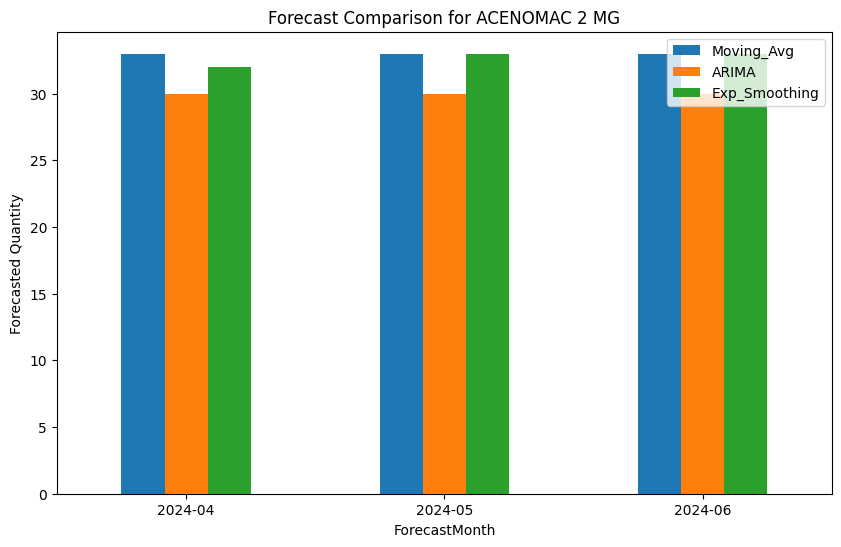

In [ ]:
sample = forecast_comparison[forecast_comparison['Product'] == 'ACENOMAC 2 MG']

sample.plot(x='ForecastMonth', y=['Moving_Avg', 'ARIMA', 'Exp_Smoothing'], kind='bar', figsize=(10, 6))
plt.title('Forecast Comparison for ACENOMAC 2 MG')
plt.ylabel('Forecasted Quantity')
plt.xticks(rotation=0)
plt.show()


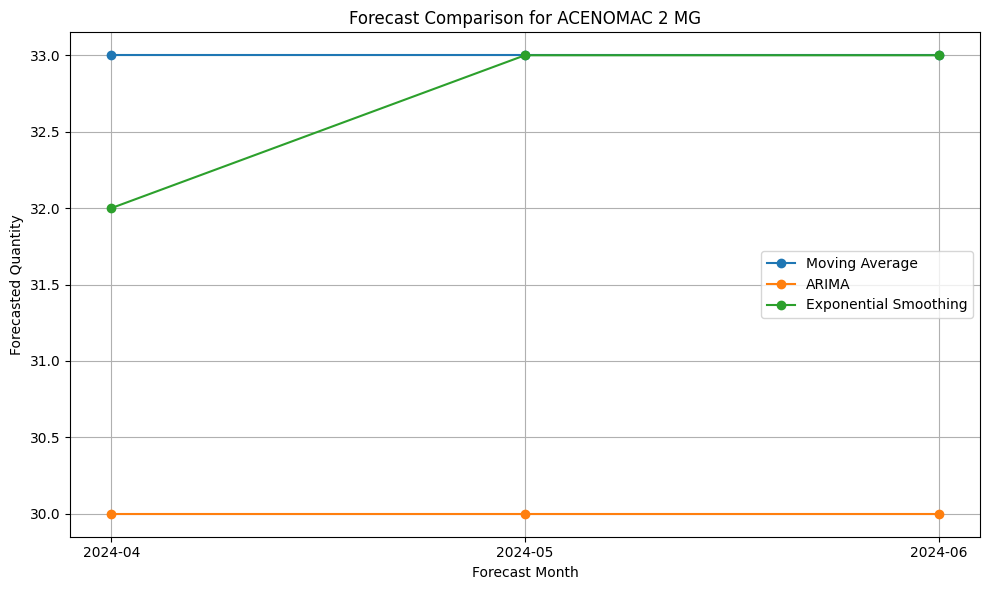

In [ ]:
# Filter for the sample product
sample = forecast_comparison[forecast_comparison['Product'] == 'ACENOMAC 2 MG']

# Set the ForecastMonth as index for plotting
sample.set_index('ForecastMonth', inplace=True)

# Line plot for forecast comparison
plt.figure(figsize=(10, 6))
plt.plot(sample.index, sample['Moving_Avg'], marker='o', label='Moving Average')
plt.plot(sample.index, sample['ARIMA'], marker='o', label='ARIMA')
plt.plot(sample.index, sample['Exp_Smoothing'], marker='o', label='Exponential Smoothing')

plt.title("Forecast Comparison for ACENOMAC 2 MG")
plt.xlabel("Forecast Month")
plt.ylabel("Forecasted Quantity")
plt.xticks(rotation=0)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
